# Four-Bar Linkage Position Analysis (Newton's Method for a Nonlinear System)

This notebook computes the four-bar configuration for a sequence of input angles $\theta_2$ by solving the nonlinear loop-closure equations for the unknown angles $\theta_3$ and $\theta_4$.

We then animate the mechanism motion.

**Key idea:** For each $\theta_2$, solve the 2×2 nonlinear system
\begin{equation}
\begin{aligned}
f_1(\theta_3,\theta_4) &= r_2\cos\theta_2 + r_3\cos\theta_3 - r_1 - r_4\cos\theta_4 = 0,\\
f_2(\theta_3,\theta_4) &= r_2\sin\theta_2 + r_3\sin\theta_3 - r_4\sin\theta_4 = 0.
\end{aligned}
\end{equation}
using Newton’s method:
\begin{equation}
J\,\Delta x = -F,\qquad x \leftarrow x + \Delta x,
\end{equation}
where $x=[\theta_3,\theta_4]^T$.


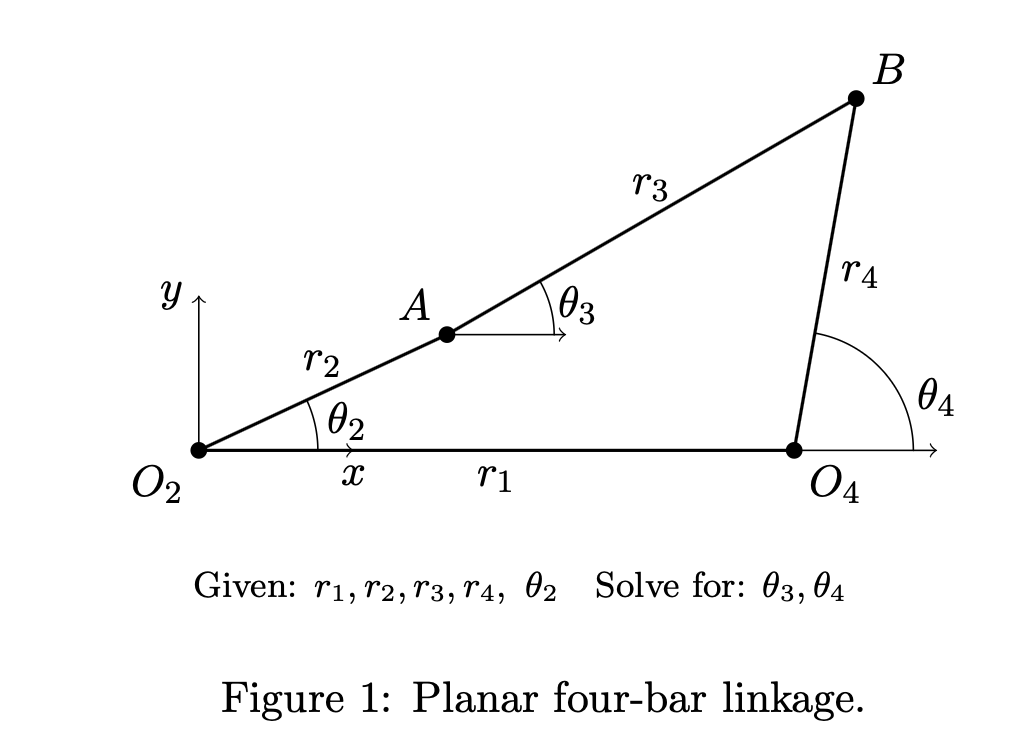

In [21]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [22]:
# Define symbols
r_1, r_2, r_3, r_4, theta_2, theta_3, theta_4 = sp.symbols('r_1,r_2,r_3,r_4,theta_2,theta_3,theta_4')

In [23]:
# Define symbolic expressions for constraint equations
f1 = r_2*sp.cos(theta_2)+r_3*sp.cos(theta_3)-r_1-r_4*sp.cos(theta_4)
f2 = r_2*sp.sin(theta_2)+r_3*sp.sin(theta_3)-r_4*sp.sin(theta_4)

In [24]:
F = sp.Matrix([f1, f2])
J = F.jacobian([theta_3, theta_4])

In [35]:
r1 = 4.0
r2 = 2.0
r3 = 3.0
r4 = 3.5
th2 = np.linspace(np.pi/8, (2.*np.pi),25)
#
niter = 8
tol = 1.0e-8
m = len(th2)
#
# Initial guess for theta_2 and theta_3
th3i = np.pi/4.
th4i = np.pi/3.
# store in numpy array
thetai = np.array([th3i,th4i])

# store joint positions
x1_hist = []
x2_hist = []
x3_hist = []
x4_hist = []


for n in range(m):
    th2n = th2[n]
    for i in range(niter):
        th3i = thetai[0]
        th4i = thetai[1]

        subs_all = {
        r_1: r1, r_2: r2, r_3: r3, r_4: r4,   # numeric values
        theta_2: float(th2n),
        theta_3: float(th3i),
        theta_4: float(th4i)
        }

        Fi = np.array(F.subs(subs_all), dtype=float).reshape(2)
        Ji = np.array(J.subs(subs_all), dtype=float).reshape(2,2)
        ri = np.linalg.norm(Fi)
        if ri < tol:
            break
        dthetai = -np.linalg.solve(Ji,Fi)
        thetai = thetai + dthetai

    x1 = np.array([0.,0.])
    x2 = np.array([r1,0.])
    x3 = np.array([r1+r4*np.cos(th4i),r4*np.sin(th4i)])
    x4 = np.array([r2*np.cos(th2n),r2*np.sin(th2n)])

    x1_hist.append(x1)
    x2_hist.append(x2)
    x3_hist.append(x3)
    x4_hist.append(x4)   

In [36]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.set_xlim(-5, 8)
ax.set_ylim(-5, 5)
ax.grid(True)

line1, = ax.plot([], [], 'k-', lw=2)
line2, = ax.plot([], [], 'b-', lw=2)
line3, = ax.plot([], [], 'r-', lw=2)
line4, = ax.plot([], [], 'g-', lw=2)
joints, = ax.plot([], [], 'ko')

def update(frame):

    x1 = x1_hist[frame]
    x2 = x2_hist[frame]
    x3 = x3_hist[frame]
    x4 = x4_hist[frame]

    line1.set_data([x1[0], x4[0]], [x1[1], x4[1]])
    line2.set_data([x4[0], x3[0]], [x4[1], x3[1]])
    line3.set_data([x3[0], x2[0]], [x3[1], x2[1]])
    line4.set_data([x2[0], x1[0]], [x2[1], x1[1]])

    joints.set_data([x1[0], x2[0], x3[0], x4[0]],
                    [x1[1], x2[1], x3[1], x4[1]])

    return line1, line2, line3, line4, joints

ani = FuncAnimation(fig, update, frames=len(th2), interval=50)
plt.close(fig)     
HTML(ani.to_jshtml())